In [46]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [47]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g8_semantic_competition_density.csv"
)

print(model_df.shape)
model_df.head()

(2255, 430)


,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,production_budget,...,g7_market_synopsis_emb_378,g7_market_synopsis_emb_379,g7_market_synopsis_emb_380,g7_market_synopsis_emb_381,g7_market_synopsis_emb_382,g7_market_synopsis_emb_383,g8_avg_semantic_similarity_nearby_20d,g8_max_semantic_similarity_nearby_20d,g8_num_high_similarity_nearby_20d,g8_sum_semantic_similarity_nearby_20d
0,tt1311067,Halloween II,2009.0,7676836.0,1217.0,1981-10-30,Wide,Wide,Universal,2500000.0,...,-0.002869,0.001596,0.017313,-0.001521,0.015695,-0.002559,0.0,0.0,0,0.0
1,tt0816462,Conan the Barbarian,2011.0,9479373.0,1358.0,1982-05-14,Wide,Wide,Universal,20000000.0,...,-0.009605,0.065961,0.064154,-0.019530,0.059167,-0.029100,0.0,0.0,0,0.0
2,tt4731008,The Wild Life,2016.0,4001400.0,1140.0,1984-09-28,Wide,Wide,NaN,NaN,...,-0.026302,0.033671,0.062510,0.022507,-0.053450,0.051958,0.0,0.0,0,0.0
3,tt1160419,Dune: Part One,2021.0,6025091.0,915.0,1984-12-14,Wide,Wide,Universal,45000000.0,...,-0.010835,0.018189,0.055949,-0.067033,-0.006612,-0.019689,0.0,0.0,0,0.0
4,tt1540128,Playing for Keeps,2012.0,1406300.0,1148.0,1986-10-03,Wide,Wide,Universal,35000000.0,...,-0.086354,0.040381,0.034655,0.020070,0.042513,-0.039980,0.0,0.0,0,0.0


In [48]:
g7_features = [col for col in model_df.columns if col.startswith("g7_")]
g8_features = [col for col in model_df.columns if col.startswith("g8_")]

In [49]:
target = "log_opening_weekend_gross"

num_group_features = [

]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g8_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [

]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    "franchise",
 ] + people_features + cat_group_feature

In [50]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [51]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 23)
(1493,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
y_test_dollars = np.expm1(y_test)

In [54]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [55]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [56]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'Ridge Baseline',
 'r2_log': 0.4263236589548256,
 'mae_log': 0.8996939211780048,
 'mae_dollars': 7648200.437009225}

In [57]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'XGBoost Baseline',
 'r2_log': 0.5089757298999813,
 'mae_log': 0.7918053553856448,
 'mae_dollars': 6141041.47244722}

In [58]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.426324,0.899694,7.648200e+06
1,XGBoost Baseline,0.508976,0.791805,6.141041e+06


In [59]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [60]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [61]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

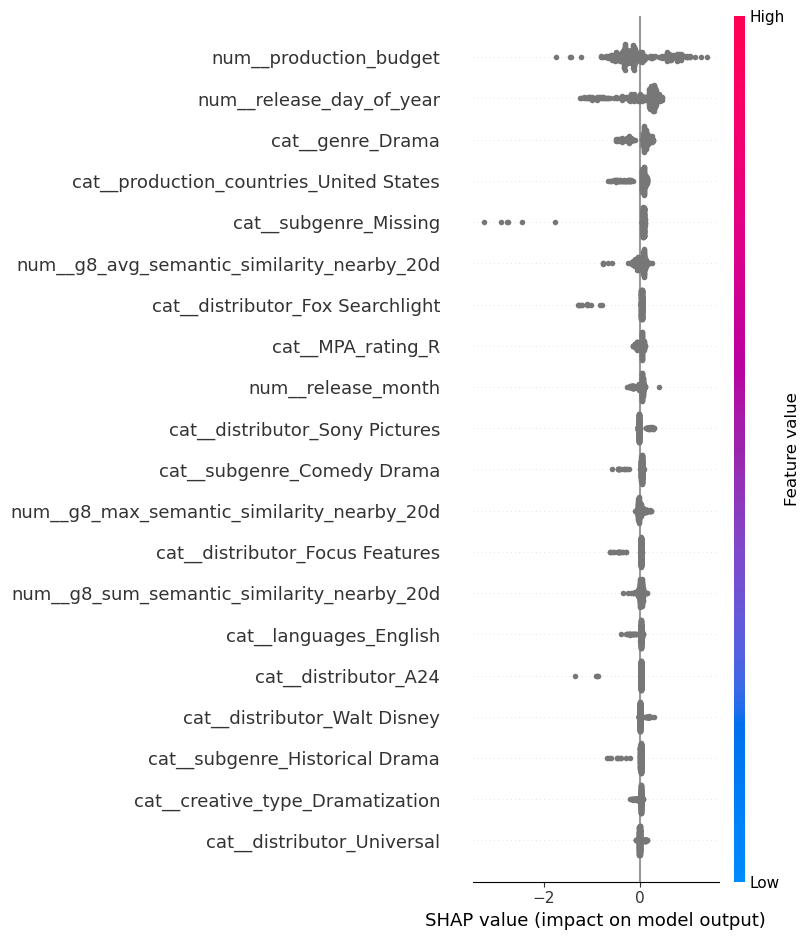

In [62]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

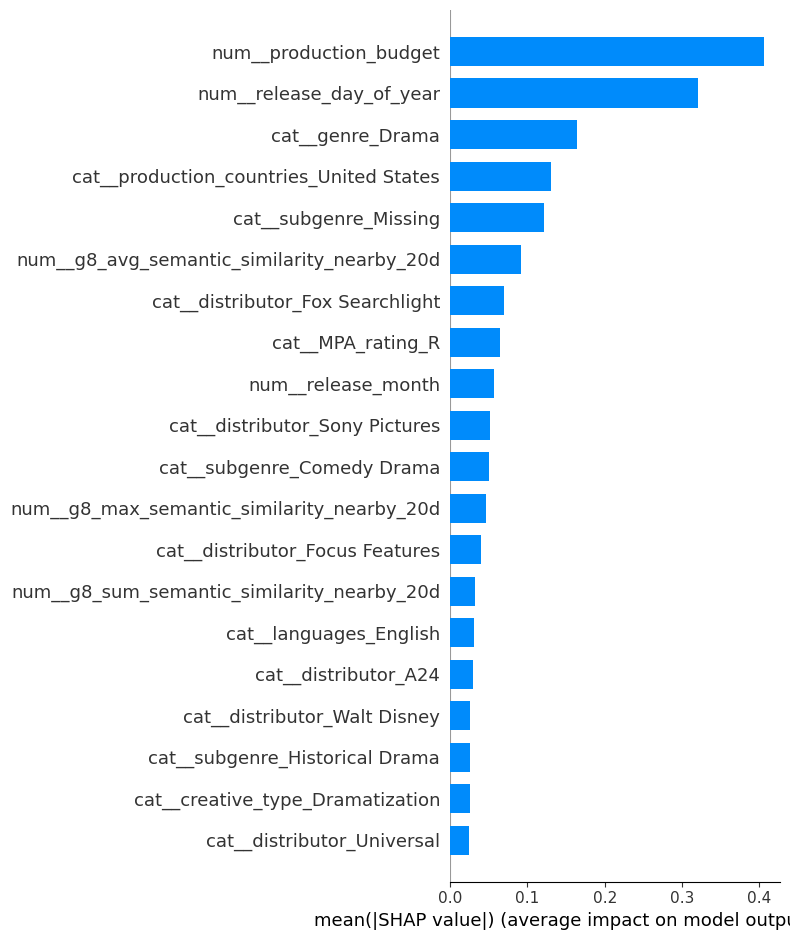

In [63]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [64]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g8_avg_semantic_similarity_nearby_20d,g8_max_semantic_similarity_nearby_20d,g8_num_high_similarity_nearby_20d,g8_sum_semantic_similarity_nearby_20d,distributor,MPA_rating,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,0.069955,0.153806,0,0.979374,Newmarket Films,R,...,nm0000154,nm0280179,nm0001029,nm0000899,nm0411581,18.244517,15.550289,83848082.0,5667672.0,78180410.0
1798,75000000.0,86.0,11,313,0.146226,0.372398,0,2.193389,Universal,PG,...,nm0155528,nm1942829,nm1212722,nm7372981,nm0429069,18.028717,17.033127,67572855.0,24968532.0,42604323.0
1393,95000000.0,105.0,3,72,0.245187,1.000000,1,2.451873,Walt Disney,PG,...,nm0000110,nm0919363,nm4141252,nm0000949,nm0534635,18.033213,17.217430,67877361.0,30021672.0,37855689.0
741,175000000.0,89.0,5,149,0.232365,0.304351,0,2.323651,Walt Disney,PG,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.243296,68108790.0,30808328.0,37300462.0
1795,55000000.0,134.0,11,306,0.102768,0.217606,0,1.541515,20th Century Fox,PG-13,...,nm0001741,nm0565026,nm1785339,nm2377903,nm3152605,17.748534,16.458714,51061119.0,14058158.0,37002961.0
1557,60000000.0,96.0,9,253,0.193770,0.365116,0,1.937704,Warner Bros.,PG-13,...,nm0000142,nm0464548,nm0000158,nm0001173,nm0001473,17.371667,15.886004,35028301.0,7928737.0,27099564.0
803,105000000.0,97.0,11,329,0.122458,0.285571,0,2.326703,Walt Disney,G,...,nm0166256,nm0166256,nm0741242,nm0202966,nm0001856,13.574955,17.104919,786190.0,26827000.0,26040810.0
1377,56200000.0,124.0,12,359,0.163566,0.287663,0,1.472092,Walt Disney,PG,...,nm0551128,nm0487567,nm0447695,nm0000658,nm1517976,17.251171,15.496900,31051923.0,5373013.0,25678910.0
1396,130000000.0,94.0,3,86,0.227195,1.000000,1,1.817563,20th Century Fox,PG,...,nm7057993,nm8289285,nm8289285,NaN,NaN,17.768824,17.108084,52107731.0,26912024.0,25195707.0
990,200000000.0,113.0,6,168,0.094859,0.270029,0,0.758869,Warner Bros.,PG-13,...,nm0132709,nm0075528,nm0005351,nm0515116,nm0765597,17.789086,17.151136,53174303.0,28095960.0,25078343.0


In [65]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g8_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g8_xgb_test_errors.csv",
    index=False
)